Purpose
-------
    Assess biogeochemical fields from ACCESS-OM2-WOMBATmid
    
    We use monthly climatologies for assessment (not specific years)
    
    The fields we are assessing are:
        1  - Surface NO3 at the equatorial band    --> World Ocean Atlas 2023 
        2  - Surface Silicic acid globally         --> World Ocean Atlas 2023 
        3  - Surface DOC concentration globally    --> Panaoitis et al. (2025)
        4  - Surface dFe globally                  --> Huang et al. 2022 Frontiers in Marine Science
        5  - Surface Chlorophyll                   --> Sauzede et al. (2016 JGR: Oceans)
        6  - Depth of max Chlorophyll              --> Sauzede et al. (2016 JGR: Oceans)
        7  - Net Primary Production                --> Carbon-based productivity model (CbPM) 
        8  - Primary nutrient limitation (N or Fe) --> Browning & Moore 2023 Nature Communications
        9  - Air-sea CO2 flux (Southern Ocean)     --> Chau et al. (2022)
        10 - Sinking POC fluxes                    --> Mouw et al. (2016)
        11 - Sinking PIC fluxes                    --> Mouw et al. (2016)
        12 - Sinking BSi fluxes                    --> Mouw et al. (2016)
        13 - Fe:C ratios of phytoplankton          --> Twining et al. (2021)
        14 - Si:C ratios of diatoms                --> Twining et al. (2021)
        15 - fraction of microphytoplankton        --> Sathyendranath et al. (2020)
        16 - NH4:DIN - pNH4:pNPP ratio             --> Buchanan et al. (2025)
        
        

## imports

In [1]:
import sys
import os

import numpy as np
import pandas as pd
import xarray as xr
import scipy as sci
import h5py as h5

import matplotlib.pyplot as plt
from matplotlib import ticker
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean.cm as cmo
from cmocean.tools import lighten

# regridding package
import xesmf as xe

# statistics package
import skill_metrics as sm

# fit b-values
from scipy.optimize import curve_fit


# print versions of packages
print("python version =",sys.version[:5])
print("numpy version =", np.__version__)
print("pandas version =", pd.__version__)
print("xarray version =", xr.__version__)
print("scipy version =", sci.__version__)
print("h5py version =", h5.__version__)
print("matplotlib version =", sys.modules[plt.__package__].__version__)
print("cmocean version =", sys.modules[cmo.__package__].__version__)
print("cartopy version =", sys.modules[ccrs.__package__].__version__)
print("xesmf version =", xe.__version__)


moddir = "/g/data/vn19/pjb581/SOTS-Optimization/WOMBATfull/"
obsdir = "/g/data/vn19/pjb581/SOTS-Optimization/WOMBATfull/data/observations"
os.chdir(obsdir)


python version = 3.10.
numpy version = 2.2.5
pandas version = 2.3.3
xarray version = 2025.4.0
scipy version = 1.15.3
h5py version = 3.15.1
matplotlib version = 3.10.6
cmocean version = v3.0.3
cartopy version = 0.24.1
xesmf version = 0.8.10


In [2]:
import warnings
warnings.filterwarnings('ignore')

### Annika broken stick b-value functions

In [3]:
%%time

# define spl model (simple power law)
def spl(x, b, cs):
    return (x / x[0]) ** (-b) * cs

# define bpl model (broken power law)
def bpl(x, b1, b2, cd, z_trans):
    return np.where(x < z_trans, (x/z_trans)**(-b1) * cd, (x/z_trans)**(-b2) * cd)

def r2_score_numpy(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

    return 1 - ss_res / ss_tot


CPU times: user 0 ns, sys: 32 μs, total: 32 μs
Wall time: 16.7 μs


# start up a dask client

In [4]:
import dask
from dask.distributed import Client, LocalCluster
cluster = LocalCluster(n_workers=56, threads_per_worker=1, memory_limit="8GB")
client  = Client(cluster)
client  # shows dashboard link



Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 56
Total threads: 56,Total memory: 417.23 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:33839,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:44363,Total threads: 1
Dashboard: /proxy/34719/status,Memory: 7.45 GiB
Nanny: tcp://127.0.0.1:45999,


2026-08-24 14:57:21,944 - tornado.application - ERROR - Uncaught exception GET /individual-task-stream/ws (127.0.0.1)
HTTPServerRequest(protocol='http', host='gadi-cpu-bdw-0611.gadi.nci.org.au:56139', method='GET', uri='/individual-task-stream/ws', version='HTTP/1.1', remote_ip='127.0.0.1')
Traceback (most recent call last):
  File "/g/data/es60/pjb581/miniforge3/envs/model_assessment_env/lib/python3.10/site-packages/tornado/websocket.py", line 965, in _accept_connection
    open_result = handler.open(*handler.open_args, **handler.open_kwargs)
  File "/g/data/es60/pjb581/miniforge3/envs/model_assessment_env/lib/python3.10/site-packages/tornado/web.py", line 3375, in wrapper
    return method(self, *args, **kwargs)
  File "/g/data/es60/pjb581/miniforge3/envs/model_assessment_env/lib/python3.10/site-packages/bokeh/server/views/ws.py", line 149, in open
    raise ProtocolError("Token is expired. Configure the app with a larger value for --session-token-expiration if necessary")
bokeh.prot

## load data

In [49]:
%%time

os.chdir(obsdir)

bottle_data = xr.open_dataset("sots_monthly_climatology.nc").squeeze()
pco2_data = xr.open_dataset("sots_sofs_pco2_monthly_climatology.nc").squeeze()
chl_data = xr.open_dataset("sots_chl_30m_monthly_climatology.nc").squeeze()
zoo_data = xr.open_dataset("maredat_zoo.nc").squeeze()
bac_data = pd.read_csv("TAN1810_Bacteria_Salp_biomass_converted_mmolC_m3.csv")

### cut out depths > 500 metres
bottle_data = bottle_data.sel(depth=slice(0,500))
zoo_data = zoo_data.sel(DEPTH=slice(0,500))

### Bacterial data
bac_data = bac_data[['Depth water [m]','Bact C [mmol C/m**3] (20 fg C/cell)']]
bac_data = bac_data.sort_values(by='Depth water [m]', ascending=True)
bac_data = bac_data.rename(columns={'Depth water [m]':'depth', 'Bact C [mmol C/m**3] (20 fg C/cell)':'bac'})
bac_data_mean = bac_data.groupby('depth', as_index=False).mean()
bac_data_std = bac_data.groupby('depth', as_index=False).std()
bac_data_mean
bac_data_smooth = pd.DataFrame({
    'depth':bac_data_mean['depth'].values, 
    'mean':bac_data_mean['bac'].values, 
    'std':bac_data_std['bac'].values
})
bac_data_smooth

### Argo data
argo_data = xr.open_dataset("ARGO_SOTS.nc").squeeze()
argo_data


CPU times: user 369 ms, sys: 120 ms, total: 489 ms
Wall time: 797 ms


<xarray.Dataset> Size: 444kB
Dimensions:   (pressure: 1501, month: 12)
Coordinates:
  * pressure  (pressure) int64 12kB 0 1 2 3 4 5 ... 1496 1497 1498 1499 1500
  * month     (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    POC       (pressure, month) float64 144kB ...
    CHL       (pressure, month) float64 144kB ...
    NO3       (pressure, month) float64 144kB ...

## Now, load the model output

In [7]:
%%time

vars2d = ['pco2', 'dic_stf', 'mlotst']
vars3d = ['thetao', 'so', 
          'phy', 'dia', 'pchl', 'dchl', 
          'o2', 'no3', 'nh4', 'fe', 'sil',
          'sdet', 'ldet', 'sdet_vmove', 'ldet_vmove',
          'zoo', 'mes', 'lbac', 'obac', 'sbac']

mod = {}
for i in range(1, 2049):
    if i % 50 == 0: print(i)
    for vv in vars2d:
        mod[vv + "_%i"%(i)] = xr.open_dataset(f'/scratch/es60/pjb581/access-om3/archive/om3_mom6_1D-SOTSfull%i/output009/access-om3.mom6.2d.%s.1day.mean.1909.nc'%(i,vv))[vv].isel(yh=1,xh=1)
    for vv in vars3d:
        mod[vv + "_%i"%(i)] = xr.open_dataset(f'/scratch/es60/pjb581/access-om3/archive/om3_mom6_1D-SOTSfull%i/output009/access-om3.mom6.3d.%s.1day.mean.1909.nc'%(i,vv))[vv].isel(yh=1,xh=1)



50
100
150
200
250
300
350
400
450
500
550
600
650
700
750
800
850
900
950
1000
1050
1100
1150
1200
1250
1300
1350
1400
1450
1500
1550
1600
1650
1700
1750
1800
1850
1900
1950
2000
CPU times: user 28min 9s, sys: 7min 27s, total: 35min 36s
Wall time: 41min 51s


### Calculate the b values in the upper and lower water column

In [12]:
def fit_one_experiment_light(exp, sdet, ldet, mlotst, phy, dia, depth_full):

    depth_da = xr.DataArray(
        depth_full,
        dims=["zl"],
        coords={"zl": depth_full}
    )

    poc = (sdet + ldet) * 1.035 * 1e6
    zprod = mlotst
    living = (phy + dia) * 1.035 * 1e6
    D2L = poc / living

    poc_interp = poc.interp(zl=depth_full).transpose("time", "zl")

    mask = (
        (depth_da > zprod) &
        (depth_da < 1000.0)
    ).transpose("time", "zl")

    poc_masked = poc_interp.where(mask)
    depth_2d = depth_da.broadcast_like(poc_masked)
    depth_masked = depth_2d.where(mask)

    time_coord = poc_masked["time"]
    ntime = poc_masked.sizes["time"]

    b_spl      = np.full(ntime, np.nan)
    r2_spl     = np.full(ntime, np.nan)
    b1_bpl     = np.full(ntime, np.nan)
    b2_bpl     = np.full(ntime, np.nan)
    cd_bpl     = np.full(ntime, np.nan)
    ztrans_bpl = np.full(ntime, np.nan)
    r2_bpl     = np.full(ntime, np.nan)

    poc_arr = poc_masked.values
    dep_arr = depth_masked.values
    zprod_arr = zprod.values

    for tt in range(ntime):

        poc_t = poc_arr[tt, :]
        dep_t = dep_arr[tt, :]
        zprod_t = float(zprod_arr[tt])

        valid = np.isfinite(poc_t) & np.isfinite(dep_t) & (poc_t > 0)

        if valid.sum() < 10:
            continue

        poc_fit = poc_t[valid]
        dep_fit = dep_t[valid]

        try:
            popt_spl, _ = curve_fit(
                spl,
                dep_fit,
                poc_fit,
                sigma=0.6 * poc_fit,
                p0=[0.3, 50],
                bounds=([-10, 0], [10, 150]),
                ftol=1e-3,
                maxfev=5000
            )

            y_pred_spl = spl(dep_fit, *popt_spl)

            b_spl[tt] = popt_spl[0]
            r2_spl[tt] = r2_score_numpy(poc_fit, y_pred_spl)

        except Exception:
            pass

        try:
            popt_bpl, _ = curve_fit(
                bpl,
                dep_fit,
                poc_fit,
                sigma=0.6 * poc_fit,
                p0=[0.5, 0.3, 10, zprod_t + 100],
                bounds=(
                    [-10, -10, 0, zprod_t],
                    [10, 10, 150, zprod_t + 300]
                ),
                ftol=1e-3,
                maxfev=5000
            )

            y_pred_bpl = bpl(dep_fit, *popt_bpl)

            b1_bpl[tt]     = popt_bpl[0]
            b2_bpl[tt]     = popt_bpl[1]
            cd_bpl[tt]     = popt_bpl[2]
            ztrans_bpl[tt] = popt_bpl[3]
            r2_bpl[tt]     = r2_score_numpy(poc_fit, y_pred_bpl)

        except Exception:
            pass

    result = xr.Dataset(
        {
            "b_spl":      ("time", b_spl),
            "r2_spl":     ("time", r2_spl),
            "b1_bpl":     ("time", b1_bpl),
            "b2_bpl":     ("time", b2_bpl),
            "cd_bpl":     ("time", cd_bpl),
            "ztrans_bpl": ("time", ztrans_bpl),
            "r2_bpl":     ("time", r2_bpl),
            "D2L":        D2L,
        },
        coords={"time": time_coord}
    )

    return exp, result

In [13]:
%%time

from dask import delayed, compute

depth_full = np.arange(0, 1100, 1)
exps = np.arange(1, 2049, 1)

tasks = [
    delayed(fit_one_experiment_light)(
        exp,
        mod["sdet_%i" % exp],
        mod["ldet_%i" % exp],
        mod["mlotst_%i" % exp],
        mod["phy_%i" % exp],
        mod["dia_%i" % exp],
        depth_full
    )
    for exp in exps
]

results = compute(*tasks)

fit_ds = xr.concat(
    [result.expand_dims(exp=[exp]) for exp, result in results],
    dim="exp"
)

fit_ds.to_netcdf(moddir + "data/output/poc_attenuation_fits_2048exp.nc")

CPU times: user 6min 46s, sys: 1min 39s, total: 8min 26s
Wall time: 22min 4s


In [14]:
fit_ds_monthly = fit_ds.groupby("time.month").mean("time", skipna=True)
fit_ds_monthly

<xarray.Dataset> Size: 9MB
Dimensions:     (month: 12, exp: 2048, zl: 75)
Coordinates:
  * exp         (exp) int64 16kB 1 2 3 4 5 6 7 ... 2043 2044 2045 2046 2047 2048
    xh          float64 8B 142.2
    yh          float64 8B -47.25
  * zl          (zl) float64 600B 0.5413 1.681 2.94 ... 5.511e+03 5.805e+03
  * month       (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    b_spl       (month, exp) float64 197kB 0.5425 1.093 1.315 ... 0.8935 1.137
    r2_spl      (month, exp) float64 197kB 0.7625 0.9201 0.884 ... 0.9736 0.9241
    b1_bpl      (month, exp) float64 197kB 1.065 1.854 2.281 ... 0.9705 1.42
    b2_bpl      (month, exp) float64 197kB 0.3833 1.077 1.35 ... 0.8882 1.155
    cd_bpl      (month, exp) float64 197kB 0.08629 0.2416 ... 0.1485 0.1147
    ztrans_bpl  (month, exp) float64 197kB 206.0 85.11 103.0 ... 88.45 91.09
    r2_bpl      (month, exp) float64 197kB 0.9691 0.9861 ... 0.9951 0.9549
    D2L         (month, exp, zl) float32 7MB 0.1985 0.2031 ... 8.125 8.125

In [15]:
%%time

# Monthly coordinate
months = np.arange(1, 13)

# Seasonal b1 cycle
# High in peak summer, low in peak winter.
# For Southern Hemisphere:
# peak summer = January/February-ish
# peak winter = July/August-ish
b1_max = 1.5
b1_min = 0.7

b1_mean = (b1_max + b1_min) / 2
b1_amp  = (b1_max - b1_min) / 2

# Peak at month 1, minimum at month 7
b1 = b1_mean + b1_amp * np.cos(2 * np.pi * (months - 1) / 12)

# Constant b2
b2 = np.full_like(b1, 0.2, dtype=float)

# Difference
b1_minus_b2 = b1 - b2

# Build dataset
ideal_monthly = xr.Dataset(
    {
        "b1_bpl": ("month", b1),
        "b2_bpl": ("month", b2),
        "b1_minus_b2": ("month", b1_minus_b2),
    },
    coords={
        "month": months
    }
)

ideal_monthly

CPU times: user 4.3 ms, sys: 2.99 ms, total: 7.29 ms
Wall time: 17.4 ms


<xarray.Dataset> Size: 384B
Dimensions:      (month: 12)
Coordinates:
  * month        (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    b1_bpl       (month) float64 96B 1.5 1.446 1.3 1.1 0.9 ... 0.9 1.1 1.3 1.446
    b2_bpl       (month) float64 96B 0.2 0.2 0.2 0.2 0.2 ... 0.2 0.2 0.2 0.2 0.2
    b1_minus_b2  (month) float64 96B 1.3 1.246 1.1 0.9 0.7 ... 0.7 0.9 1.1 1.246

### Convert model data to observations grid

In [16]:
%%time

target_depth = bottle_data.depth
target_month = bottle_data.month

for i in range(1, 2049):
    if i % 50 == 0: print(i)
    for vv in np.concatenate((vars2d, vars3d)):
        mod[vv + "_%i_obsgrid"%(i)] = mod[vv + "_%i"%(i)].groupby("time.month").mean("time")
        if vv in vars3d:
            mod[vv + "_%i_obsgrid"%(i)] = mod[vv + "_%i_obsgrid"%(i)].interp(zl=target_depth)
            
mod['phy_1_obsgrid']

50
100
150
200
250
300
350
400
450
500
550
600
650
700
750
800
850
900
950
1000
1050
1100
1150
1200
1250
1300
1350
1400
1450
1500
1550
1600
1650
1700
1750
1800
1850
1900
1950
2000
CPU times: user 23min 14s, sys: 4min 44s, total: 27min 58s
Wall time: 28min 51s


<xarray.DataArray 'phy' (month: 12, depth: 26)> Size: 2kB
array([[           nan, 1.55854513e-06, 1.11312832e-06, 4.50384061e-07,
        1.89219522e-08, 1.51688391e-09, 5.51864101e-10, 4.68744192e-10,
        4.45136634e-10, 4.29295222e-10, 4.13408431e-10, 3.82360630e-10,
        3.01099487e-10, 1.83079321e-10, 6.71752464e-11, 2.69997435e-11,
        5.70607619e-12, 1.73209906e-12, 3.43051160e-13, 6.62183438e-14,
        1.47596804e-14, 2.92595070e-15, 4.78075361e-16, 1.52498884e-16,
        1.15140348e-17, 5.50822581e-18],
       [           nan, 1.28644070e-06, 1.17361778e-06, 1.02873878e-06,
        1.61961658e-07, 1.62635636e-09, 9.73882642e-11, 5.60818335e-11,
        5.14665063e-11, 4.90985536e-11, 4.68182712e-11, 4.26865639e-11,
        3.35588932e-11, 2.08850436e-11, 8.34892167e-12, 3.54176450e-12,
        8.60080381e-13, 2.73116398e-13, 6.20775034e-14, 1.27874855e-14,
        3.23599321e-15, 6.71262256e-16, 1.27812117e-16, 4.14071884e-17,
        3.77838780e-18, 1.81619667e-18],
       [           nan, 1.15387924e-06, 1.03440159e-06, 9.24653188e-07,
        3.30642927e-07, 6.70794444e-09, 1.64034615e-10, 9.74863759e-12,
        6.38687751e-12, 5.96892383e-12, 5.65401341e-12, 5.10718349e-12,
        4.01673895e-12, 2.55010035e-12, 1.09050968e-12, 4.82966447e-13,
        1.30471420e-13, 4.30846592e-14, 1.08616136e-14, 2.37379937e-15,
        6.62616237e-16, 1.42888760e-16, 3.03982607e-17, 9.99082632e-18,
...
        5.14030489e-07, 4.65769877e-07, 4.37566967e-07, 4.12237325e-07,
        3.86237606e-07, 3.30086747e-07, 2.83900496e-07, 2.53952721e-07,
        1.73216590e-07, 6.69686963e-08, 1.36925419e-08, 3.61782215e-09,
        2.50505359e-10, 6.28853438e-11, 4.03693194e-12, 5.94964369e-13,
        4.70183768e-14, 7.89433530e-15, 4.33147337e-16, 1.31457421e-16,
        3.08800258e-18, 1.45589319e-18],
       [           nan, 1.45026349e-06, 1.04702529e-06, 5.09588170e-07,
        1.36433991e-07, 4.73414138e-08, 4.29032184e-08, 4.07145174e-08,
        3.92791424e-08, 3.81987315e-08, 3.71607664e-08, 3.52724047e-08,
        2.54828022e-08, 1.12703575e-08, 2.47431464e-09, 7.10114797e-10,
        7.52833824e-11, 2.00207672e-11, 2.14014641e-12, 3.43842297e-13,
        4.42560308e-14, 7.82034538e-15, 7.03754664e-16, 2.16702001e-16,
        8.42111732e-18, 3.98676973e-18],
       [           nan, 1.69538944e-06, 1.00223445e-06, 5.42953711e-07,
        4.88383475e-08, 7.25677715e-09, 4.72392281e-09, 4.39159404e-09,
        4.21574003e-09, 4.08633410e-09, 3.95655914e-09, 3.67632372e-09,
        2.68341966e-09, 1.29951584e-09, 3.46241380e-10, 1.14903805e-10,
        1.62040475e-11, 4.52230022e-12, 6.38682904e-13, 1.10359614e-13,
        1.85262232e-14, 3.43583085e-15, 4.18355011e-16, 1.30766150e-16,
        7.13424781e-18, 3.39270740e-18]])
Coordinates:
    xh       float64 8B 142.2
    yh       float64 8B -47.25
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
    zl       (depth) float64 208B 0.0 20.0 40.0 60.0 ... 440.0 460.0 480.0 500.0
  * depth    (depth) float64 208B 0.0 20.0 40.0 60.0 ... 440.0 460.0 480.0 500.0
Attributes:
    units:          mol/kg
    long_name:      Phytoplankton
    cell_methods:   time: mean
    time_avg_info:  average_T1,average_T2,average_DT

### convert bacteria to model grid

CPU times: user 32 ms, sys: 4.95 ms, total: 36.9 ms
Wall time: 34.9 ms


(200.0, 0.0)

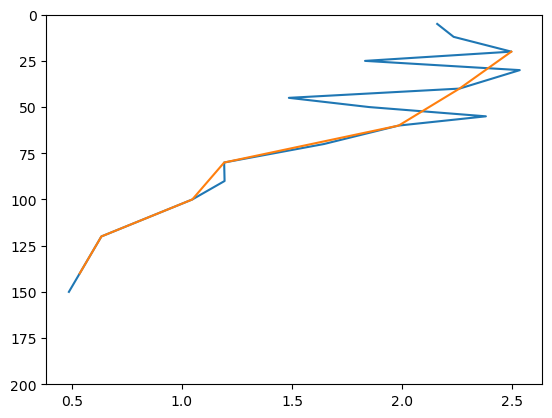

In [68]:
%%time

target_depth = bottle_data.depth
target_month = bottle_data.month

bac_xr = (
    bac_data_smooth
    .set_index("depth")
    .to_xarray()
)

bac_data_obsgrid = bac_xr.interp(depth=target_depth)

plt.figure()
plt.plot(bac_data_smooth['mean'], bac_data_smooth['depth'])
plt.plot(bac_data_obsgrid['mean'], bac_data_obsgrid['depth'])
plt.ylim(200,0)



### convert ARGO data to observation grid

CPU times: user 171 ms, sys: 21.5 ms, total: 193 ms
Wall time: 186 ms


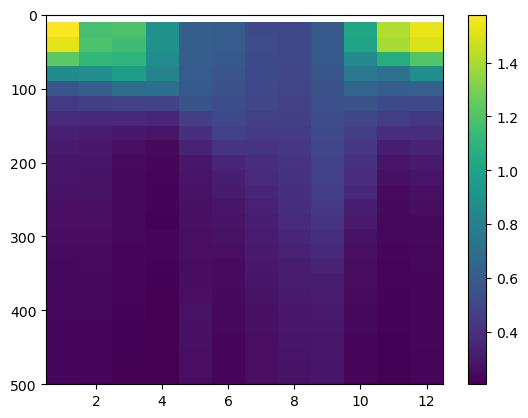

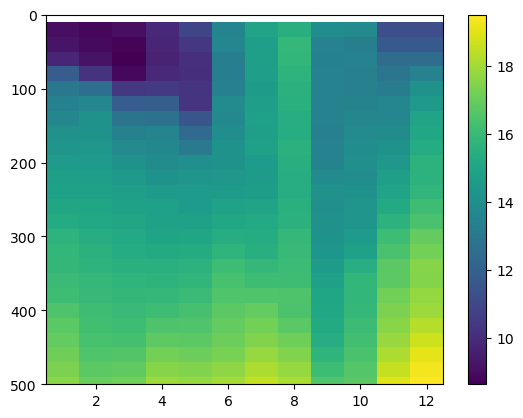

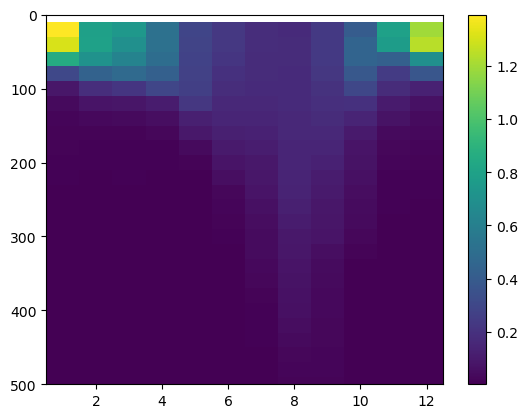

In [69]:
%%time

argo_data_obsgrid = argo_data.interp(pressure=target_depth)
argo_data_obsgrid = argo_data_obsgrid.where(argo_data_obsgrid.depth > 10.0, other=np.nan)

plt.figure()
plt.pcolormesh(argo_data_obsgrid.month, argo_data_obsgrid.depth, argo_data_obsgrid['POC']*0.5/12.0/3)
plt.ylim(500,0)
plt.colorbar()

plt.figure()
plt.pcolormesh(argo_data_obsgrid.month, argo_data_obsgrid.depth, argo_data_obsgrid['NO3'])
plt.ylim(500,0)
plt.colorbar()

plt.figure()
plt.pcolormesh(argo_data_obsgrid.month, argo_data_obsgrid.depth, argo_data_obsgrid['CHL'])
plt.ylim(500,0)
plt.colorbar()


## Assess the model fit to the observations

In [21]:
print("put all the observations into a dictionary for iteration")
obsdata = {
    'pco2': pco2_data['pco2_sw'],
    'fgco2': pco2_data['co2_flux_mol_m2_y1']*(-1),
    'nh4': bottle_data['ammonia'], 
    'no3': bottle_data['nitrate'], 
    'sil': bottle_data['silicate'], 
    'dfe': bottle_data['dFe'], 
    'poc': bottle_data['POC'], 
    'chl_bottle': bottle_data['chlorophyll_total_mv'],
    'chl_mooring': chl_data['chlorophyll'],
    'b1mb2': ideal_monthly['b1_minus_b2'],
    'D2L300mD2L50': ideal_monthly['b1_minus_b2']*0.0+2.0,
    }


put all the observations into a dictionary for iteration


In [70]:
print("put all the observations into a dictionary for iteration")
obsdata = {
    'pco2': pco2_data['pco2_sw'],
    'fgco2': pco2_data['co2_flux_mol_m2_y1'] * (-1),
    'nh4': bottle_data['ammonia'], 
    #'no3': bottle_data['nitrate'], 
    'no3': argo_data_obsgrid['NO3'], 
    'sil': bottle_data['silicate'], 
    'dfe': bottle_data['dFe'], 
    #'poc': bottle_data['POC'], 
    'poc': argo_data_obsgrid['POC']*0.5/12/3.0, 
    'bac': bac_data_obsgrid['mean'], 
    'micro': zoo_data['micro_mean'].sel(DEPTH=slice(0,500)).mean(dim='DEPTH',skipna=True)/12.0,
    'meso': zoo_data['meso_mean'].sel(DEPTH=slice(0,500)).mean(dim='DEPTH',skipna=True)/12.0,
    #'chl_bottle': bottle_data['chlorophyll_total_mv'],
    'chl_bottle': argo_data_obsgrid['CHL'],
    'chl_mooring': chl_data['chlorophyll'],
    'b1mb2': ideal_monthly['b1_minus_b2'],
    'D2L300mD2L50': ideal_monthly['b1_minus_b2']*0.5+2.0
    }


put all the observations into a dictionary for iteration


In [71]:
target_vars = np.array(list(obsdata.keys()))

for i in range(1, 2049):
    if i % 50 == 0: print(i)
    mod[target_vars[0]+"_%i"%(i)] = mod['pco2_%i_obsgrid'%(i)]
    mod[target_vars[1]+"_%i"%(i)] = mod['dic_stf_%i_obsgrid'%(i)]*365*86400
    mod[target_vars[2]+"_%i"%(i)] = mod['nh4_%i_obsgrid'%(i)]*1e6*1.035
    mod[target_vars[3]+"_%i"%(i)] = mod['no3_%i_obsgrid'%(i)]*1e6*1.035
    mod[target_vars[4]+"_%i"%(i)] = mod['sil_%i_obsgrid'%(i)]*1e6*1.035
    mod[target_vars[5]+"_%i"%(i)] = mod['fe_%i_obsgrid'%(i)]*1e9*1.035
    #mod[target_vars[6]+"_%i"%(i)] = (mod['phy_%i_obsgrid'%(i)] + mod['dia_%i_obsgrid'%(i)] + mod['det_%i_obsgrid'%(i)] + mod['bdet_%i_obsgrid'%(i)])*1e6*1.035
    mod[target_vars[6]+"_%i"%(i)] = (mod['sdet_%i_obsgrid'%(i)] + mod['ldet_%i_obsgrid'%(i)])*1e6*1.035
    mod[target_vars[7]+"_%i"%(i)] = (mod['lbac_%i_obsgrid'%(i)] + mod['obac_%i_obsgrid'%(i)] + mod['sbac_%i_obsgrid'%(i)]).sel(month=11,method='nearest')*1e6*1.035
    mod[target_vars[8]+"_%i"%(i)] = (mod['zoo_%i_obsgrid'%(i)].sel(depth=slice(0,200)).mean(dim='depth'))*1e6*1.035
    mod[target_vars[9]+"_%i"%(i)] = (mod['mes_%i_obsgrid'%(i)].sel(depth=slice(0,200)).mean(dim='depth'))*1e6*1.035
    mod[target_vars[10]+"_%i"%(i)] = (mod['pchl_%i_obsgrid'%(i)] + mod['dchl_%i_obsgrid'%(i)])*1e6*1.035*12
    mod[target_vars[11]+"_%i"%(i)] = (mod['pchl_%i_obsgrid'%(i)] + mod['dchl_%i_obsgrid'%(i)]).sel(depth=30.0,method='nearest')*1e6*1.035*12
    mod[target_vars[12]+"_%i"%(i)] = (fit_ds_monthly['b1_bpl'] - fit_ds_monthly['b2_bpl']).sel(exp=i)
    mod[target_vars[13]+"_%i"%(i)] = (fit_ds_monthly['D2L'].sel(zl=300, method='nearest') -
                                      fit_ds_monthly['D2L'].sel(zl=50, method='nearest')).sel(exp=i)




50
100
150
200
250
300
350
400
450
500
550
600
650
700
750
800
850
900
950
1000
1050
1100
1150
1200
1250
1300
1350
1400
1450
1500
1550
1600
1650
1700
1750
1800
1850
1900
1950
2000


In [24]:
target_vars = np.array(list(obsdata.keys()))

for i in range(1, 2049):
    if i % 50 == 0: print(i)
    mod[target_vars[0]+"_%i"%(i)] = mod['pco2_%i_obsgrid'%(i)]
    mod[target_vars[1]+"_%i"%(i)] = mod['dic_stf_%i_obsgrid'%(i)]*365*86400
    mod[target_vars[2]+"_%i"%(i)] = mod['nh4_%i_obsgrid'%(i)]*1e6*1.035
    mod[target_vars[3]+"_%i"%(i)] = mod['no3_%i_obsgrid'%(i)]*1e6*1.035
    mod[target_vars[4]+"_%i"%(i)] = mod['sil_%i_obsgrid'%(i)]*1e6*1.035
    mod[target_vars[5]+"_%i"%(i)] = mod['fe_%i_obsgrid'%(i)]*1e9*1.035
    mod[target_vars[6]+"_%i"%(i)] = (mod['sdet_%i_obsgrid'%(i)] + mod['ldet_%i_obsgrid'%(i)])*1e6*1.035
    mod[target_vars[7]+"_%i"%(i)] = (mod['pchl_%i_obsgrid'%(i)] + mod['pchl_%i_obsgrid'%(i)])*1e6*1.035*12
    mod[target_vars[8]+"_%i"%(i)] = (mod['pchl_%i_obsgrid'%(i)] + mod['pchl_%i_obsgrid'%(i)]).sel(depth=30.0,method='nearest')*1e6*1.035*12
    mod[target_vars[9]+"_%i"%(i)] = (fit_ds_monthly['b1_bpl'] - fit_ds_monthly['b2_bpl']).sel(exp=i)
    mod[target_vars[10]+"_%i"%(i)] = (fit_ds_monthly['D2L'].sel(zl=300, method='nearest') -
                                      fit_ds_monthly['D2L'].sel(zl=50, method='nearest')).sel(exp=i)
    



50
100
150
200
250
300
350
400
450
500
550
600
650
700
750
800
850
900
950
1000
1050
1100
1150
1200
1250
1300
1350
1400
1450
1500
1550
1600
1650
1700
1750
1800
1850
1900
1950
2000


(500.0, 0.0)

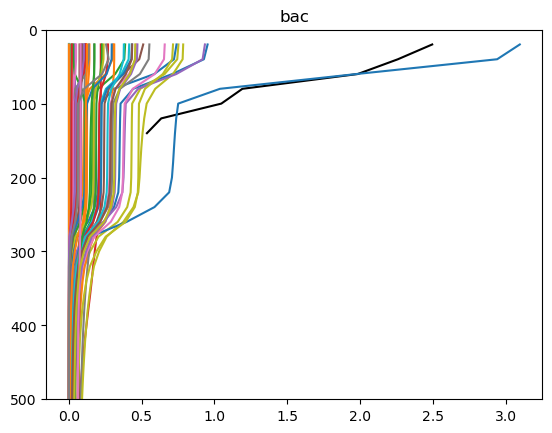

In [73]:
vv = target_vars[7]
plt.figure()
plt.title(vv)
plt.plot(obsdata[vv], target_depth, 'k')
for i in np.arange(1,50,1):
    plt.plot(mod[vv+"_%i"%(i)], target_depth)
plt.ylim(500,0)


chl_bottle


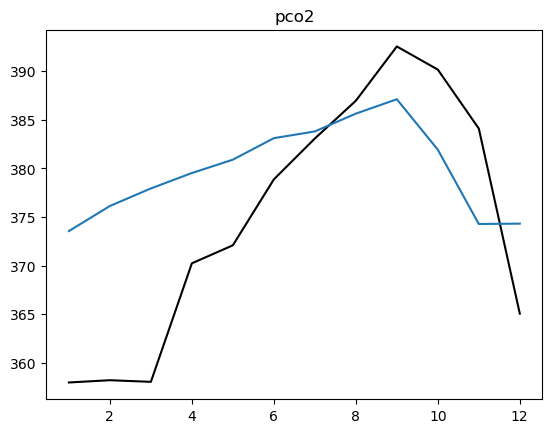

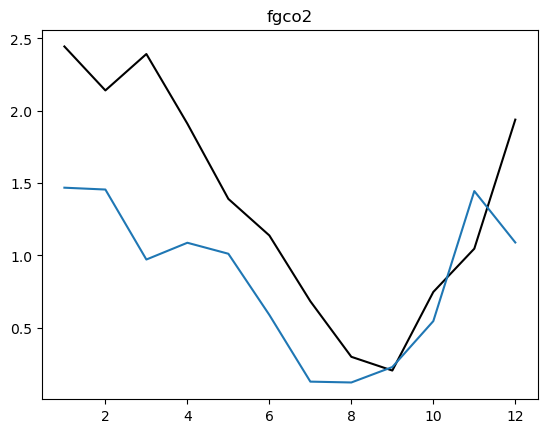

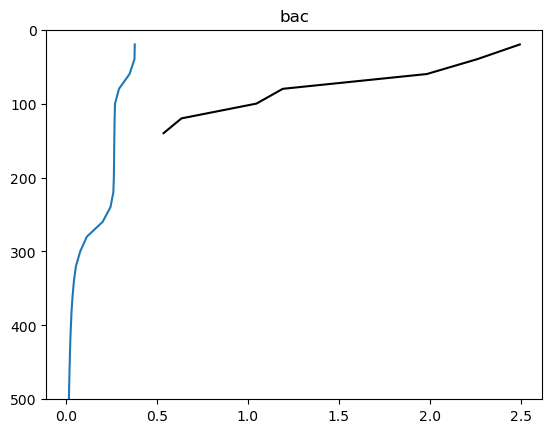

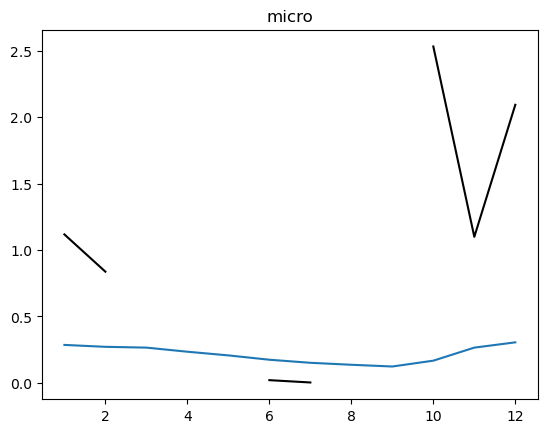

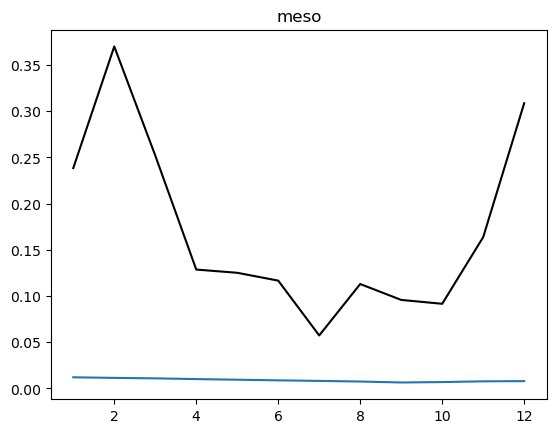

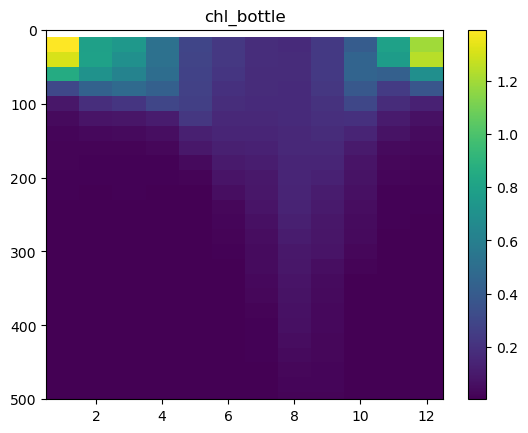

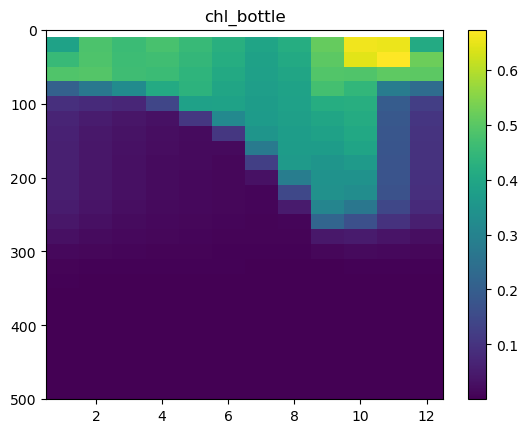

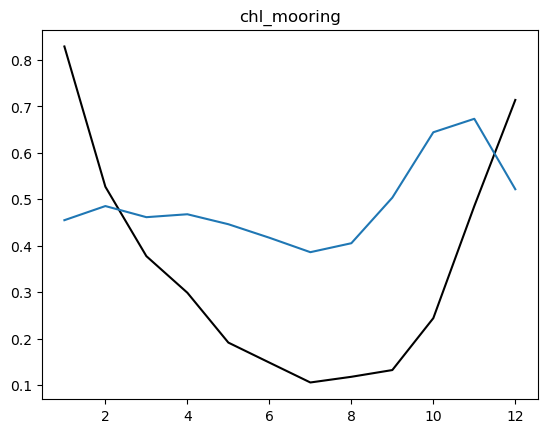

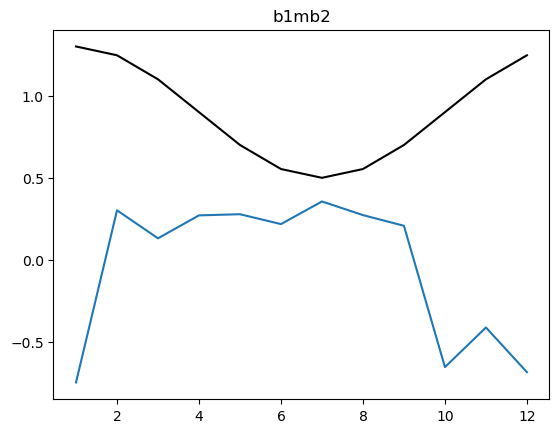

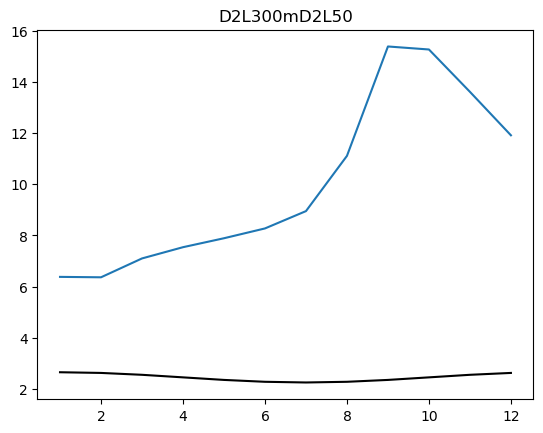

In [74]:
i = 40

vv = target_vars[0]
plt.figure()
plt.title(vv)
plt.plot(target_month, obsdata[vv], 'k')
plt.plot(target_month, mod[vv+"_%i"%(i)])

vv = target_vars[1]
plt.figure()
plt.title(vv)
plt.plot(target_month, obsdata[vv], 'k')
plt.plot(target_month, mod[vv+"_%i"%(i)])

vv = target_vars[7]
plt.figure()
plt.title(vv)
plt.plot(obsdata[vv], target_depth, 'k')
plt.plot(mod[vv+"_%i"%(i)], target_depth)
plt.ylim(500,0)

vv = target_vars[8]
plt.figure()
plt.title(vv)
plt.plot(target_month, obsdata[vv], 'k')
plt.plot(target_month, mod[vv+"_%i"%(i)])

vv = target_vars[9]
plt.figure()
plt.title(vv)
plt.plot(target_month, obsdata[vv], 'k')
plt.plot(target_month, mod[vv+"_%i"%(i)])

vv = target_vars[10]
print(vv)
plt.figure()
plt.title(vv)
plt.pcolormesh(target_month, target_depth, obsdata[vv])
plt.colorbar()
plt.ylim(500,0)
plt.figure()
plt.title(vv)
plt.pcolormesh(target_month, target_depth, mod[vv+"_%i"%(i)].T)
plt.colorbar()
plt.ylim(500,0)

vv = target_vars[11]
plt.figure()
plt.title(vv)
plt.plot(target_month, obsdata[vv], 'k')
plt.plot(target_month, mod[vv+"_%i"%(i)])

vv = target_vars[12]
plt.figure()
plt.title(vv)
plt.plot(target_month, obsdata[vv], 'k')
plt.plot(target_month, mod[vv+"_%i"%(i)])

vv = target_vars[13]
plt.figure()
plt.title(vv)
plt.plot(target_month, obsdata[vv], 'k')
plt.plot(target_month, mod[vv+"_%i"%(i)])

In [75]:

print("create the dictionary for holding the statistics")
stats = {}


for exp in np.arange(1,2049):
    for vv in target_vars:
        if (vv == "pco2") or (vv == 'fgco2') or (vv == "chl_mooring") \
        or (vv == "bac") or (vv == "micro") or (vv == 'meso') \
        or (vv == "b1mb2") or (vv == 'D2L300mD2L50'):
            predicted = mod[vv+"_%i"%(exp)].values
            observed = obsdata[vv].values
        else:
            predicted = mod[vv+"_%i"%(exp)].values.ravel()
            observed = obsdata[vv].values.ravel()
        
        # remove NaNs
        pred_good = ~np.isnan(predicted)
        obs_good = ~np.isnan(observed)
        good = pred_good * obs_good
        predicted = predicted[good]
        observed = observed[good]
        if np.std(predicted) == 0.0:
            predicted[-1] = predicted[-1]+1e-10

        if exp == 1:
            stats[vv+'_sdev'] = sm.taylor_statistics(predicted, observed)['sdev']
            stats[vv+'_nsdev'] = (sm.taylor_statistics(predicted, observed)['sdev']/sm.taylor_statistics(predicted, observed)['sdev'][0]).tolist()
            stats[vv+'_crmsd'] = sm.taylor_statistics(predicted, observed)['crmsd']
            stats[vv+'_rmse'] = np.array([0.0, sm.rmsd(predicted, observed)]).tolist()
            stats[vv+'_nrmse'] = np.array([0.0, sm.rmsd((predicted - np.mean(predicted))/np.std(predicted), (observed - np.mean(observed))/np.std(observed))]).tolist()
            stats[vv+'_ccoef'] = sm.taylor_statistics(predicted, observed)['ccoef'].tolist()
            stats[vv+'_bias'] = np.array([0.0, np.mean(predicted - observed)]).tolist()
        else:
            stats[vv+'_sdev'].append(sm.taylor_statistics(predicted, observed)['sdev'][1])
            stats[vv+'_nsdev'].append(sm.taylor_statistics(predicted, observed)['sdev'][1]/sm.taylor_statistics(predicted, observed)['sdev'][0])
            stats[vv+'_crmsd'].append(sm.taylor_statistics(predicted, observed)['crmsd'][1])
            stats[vv+'_ccoef'].append(sm.taylor_statistics(predicted, observed)['ccoef'][1])
            stats[vv+'_bias'].append(np.mean(predicted - observed))
            stats[vv+'_rmse'].append(sm.rmsd(predicted, observed))
            stats[vv+'_nrmse'].append(sm.rmsd((predicted - np.mean(predicted))/np.std(predicted), (observed - np.mean(observed))/np.std(observed)))
            


create the dictionary for holding the statistics


## save the statistics

In [80]:

os.chdir(moddir + "data/output/")
os.getcwd()


'/g/data/vn19/pjb581/SOTS-Optimization/WOMBATfull/data/output'

In [81]:
df_stats = pd.DataFrame(stats)
df_stats


,pco2_sdev,pco2_nsdev,pco2_crmsd,pco2_rmse,pco2_nrmse,pco2_ccoef,pco2_bias,fgco2_sdev,fgco2_nsdev,fgco2_crmsd,...,b1mb2_nrmse,b1mb2_ccoef,b1mb2_bias,D2L300mD2L50_sdev,D2L300mD2L50_nsdev,D2L300mD2L50_crmsd,D2L300mD2L50_rmse,D2L300mD2L50_nrmse,D2L300mD2L50_ccoef,D2L300mD2L50_bias
0,12.370366,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.759892,1.000000,0.000000,...,0.000000,1.000000,0.000000,0.141421,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
1,8.868969,0.716953,14.602082,15.785903,1.353406,0.084146,5.997827,0.854401,1.124372,1.033720,...,1.573222,-0.237514,-0.145277,106033.546875,749770.400286,106033.635905,119578.966089,1.792654,-0.606803,55281.071506
2,9.901480,0.800419,17.427272,29.523826,1.558783,-0.214902,-23.831628,0.989064,1.301585,1.286775,...,1.654260,-0.368288,0.431971,0.299247,2.115999,0.269921,1.871062,1.064421,0.433504,-1.851490
3,5.846768,0.472643,16.311619,22.193251,1.757927,-0.545154,15.048970,0.621948,0.818469,1.193764,...,1.712664,-0.466610,2.210370,0.185699,1.313094,0.177018,2.139207,1.057608,0.440733,-2.131870
4,9.369269,0.757396,21.079332,24.417247,1.938055,-0.878028,12.323300,1.058222,1.392597,1.769454,...,1.504532,-0.131808,-0.488591,0.033761,0.238728,0.130663,2.454835,1.071535,0.425907,-2.451355
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2044,9.266212,0.749065,15.125111,15.163770,1.382648,0.044142,1.082096,0.930783,1.224889,1.124443,...,1.657909,-0.374332,-0.254281,0.890943,6.299922,0.852756,1.109075,1.145768,0.343608,-0.709123
2045,6.703339,0.541887,18.308722,18.316027,1.911842,-0.827569,0.517241,0.809173,1.064853,1.469233,...,1.942484,-0.886622,-0.817994,0.193316,1.366952,0.135536,1.860024,0.757251,0.713286,-1.855079
2046,7.419615,0.599789,17.137791,20.167260,1.712579,-0.466464,10.630828,0.768977,1.011957,1.318028,...,1.694105,-0.434996,-0.388447,8.077248,57.114766,8.155645,11.302454,1.759710,-0.548290,7.825019
2047,2.250632,0.181937,14.234850,15.177567,1.897308,-0.799889,-5.265700,0.348710,0.458895,0.953636,...,1.529764,-0.170089,-0.677239,1.653886,11.694742,1.687237,1.811193,1.546251,-0.195446,0.658522


In [83]:
df_stats.sort_values(by="fgco2_ccoef", ascending=False)

,pco2_sdev,pco2_nsdev,pco2_crmsd,pco2_rmse,pco2_nrmse,pco2_ccoef,pco2_bias,fgco2_sdev,fgco2_nsdev,fgco2_crmsd,...,b1mb2_nrmse,b1mb2_ccoef,b1mb2_bias,D2L300mD2L50_sdev,D2L300mD2L50_nsdev,D2L300mD2L50_crmsd,D2L300mD2L50_rmse,D2L300mD2L50_nrmse,D2L300mD2L50_ccoef,D2L300mD2L50_bias
0,12.370366,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.759892,1.000000,0.000000,...,0.000000,1.000000,0.000000,0.141421,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
1741,24.281718,1.962894,12.796699,13.867493,0.269864,0.963587,5.343393,2.678776,3.525208,1.957883,...,1.773916,-0.573388,-0.712286,1.453225,10.275855,1.401100,2.274025,1.085701,0.410627,1.791120
1283,12.851264,1.038875,4.332377,8.250961,0.341484,0.941694,7.022028,1.418000,1.866056,0.736881,...,1.692100,-0.431602,-0.069875,1.255422,8.877175,1.224109,1.340632,1.204177,0.274979,0.546672
1439,5.920138,0.478574,7.204818,13.518325,0.375098,0.929651,11.438343,0.648964,0.854022,0.268046,...,1.716262,-0.472778,-0.466464,0.679909,4.807683,0.681848,1.545562,1.348873,0.090271,-1.387027
1751,14.727595,1.190555,5.366559,6.351916,0.357185,0.936210,3.398070,1.650943,2.172603,0.973713,...,1.550222,-0.201594,-0.481449,6.164778,43.591565,6.210450,9.023575,1.620296,-0.312680,6.546389
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1994,5.436468,0.439475,17.547772,19.877045,1.965657,-0.931904,9.336628,0.593123,0.780536,1.338821,...,1.655955,-0.371093,-0.684317,0.575889,4.072148,0.571299,1.345127,1.299914,0.155112,-1.217779
1928,4.851638,0.392198,17.045755,20.051376,1.974682,-0.949684,10.559351,0.531472,0.699405,1.278076,...,1.839917,-0.692647,-0.484294,32.829567,232.140094,32.941146,49.104149,1.891121,-0.788170,36.415634
876,5.840073,0.472102,17.928278,21.305151,1.964397,-0.929427,11.510268,0.645948,0.850053,1.391472,...,1.439229,-0.035690,-0.123639,0.144291,1.020289,0.137376,2.126527,0.961481,0.537778,-2.122085
628,4.605139,0.372272,16.678970,20.138282,1.955714,-0.912408,11.285494,0.503929,0.663160,1.251441,...,1.650093,-0.361404,-0.502690,0.147788,1.045021,0.093012,2.140577,0.641861,0.794007,-2.138555


In [84]:
os.getcwd()

'/g/data/vn19/pjb581/SOTS-Optimization/WOMBATfull/data/output'

In [85]:
print("Saving the global skill")

cols_to_drop = [column for column in df_stats.columns if '_rmse' not in column]
df_rmse = df_stats.drop(columns=cols_to_drop).drop(0)
df_rmse['sum_rmse'] = df_rmse.sum(axis=1)
df_rmse.to_excel('sensitivity_RMSE.xlsx', index=False)

cols_to_drop = [column for column in df_stats.columns if '_nrmse' not in column]
df_nrmse = df_stats.drop(columns=cols_to_drop).drop(0)
df_nrmse['sum_nrmse'] = df_nrmse.sum(axis=1)
df_nrmse.to_excel('sensitivity_NRMSE.xlsx', index=False)

cols_to_drop = [column for column in df_stats.columns if '_sdev' not in column]
df_sdev = df_stats.drop(columns=cols_to_drop).drop(0)
df_sdev['sum_sdev'] = df_sdev.sum(axis=1)
df_sdev.to_excel('sensitivity_SDEV.xlsx', index=False)

cols_to_drop = [column for column in df_stats.columns if '_nsdev' not in column]
df_nsdev = df_stats.drop(columns=cols_to_drop).drop(0)
df_nsdev['sum_nsdev'] = df_nsdev.sum(axis=1)
df_nsdev.to_excel('sensitivity_NSDEV.xlsx', index=False)

cols_to_drop = [column for column in df_stats.columns if '_bias' not in column]
df_bias = df_stats.drop(columns=cols_to_drop).drop(0)
df_bias['sum_bias'] = df_bias.sum(axis=1)
df_bias.to_excel('sensitivity_BIAS.xlsx', index=False)

cols_to_drop = [column for column in df_stats.columns if '_ccoef' not in column]
df_ccoef = df_stats.drop(columns=cols_to_drop).drop(0)
df_ccoef['sum_ccoef'] = df_ccoef.sum(axis=1)
df_ccoef.to_excel('sensitivity_CCOEF.xlsx', index=False)



Saving the global skill


## make a Taylor Diagram of the results

In [86]:
target_vars

array(['pco2', 'fgco2', 'nh4', 'no3', 'sil', 'dfe', 'poc', 'bac', 'micro',
       'meso', 'chl_bottle', 'chl_mooring', 'b1mb2', 'D2L300mD2L50'],
      dtype='<U12')

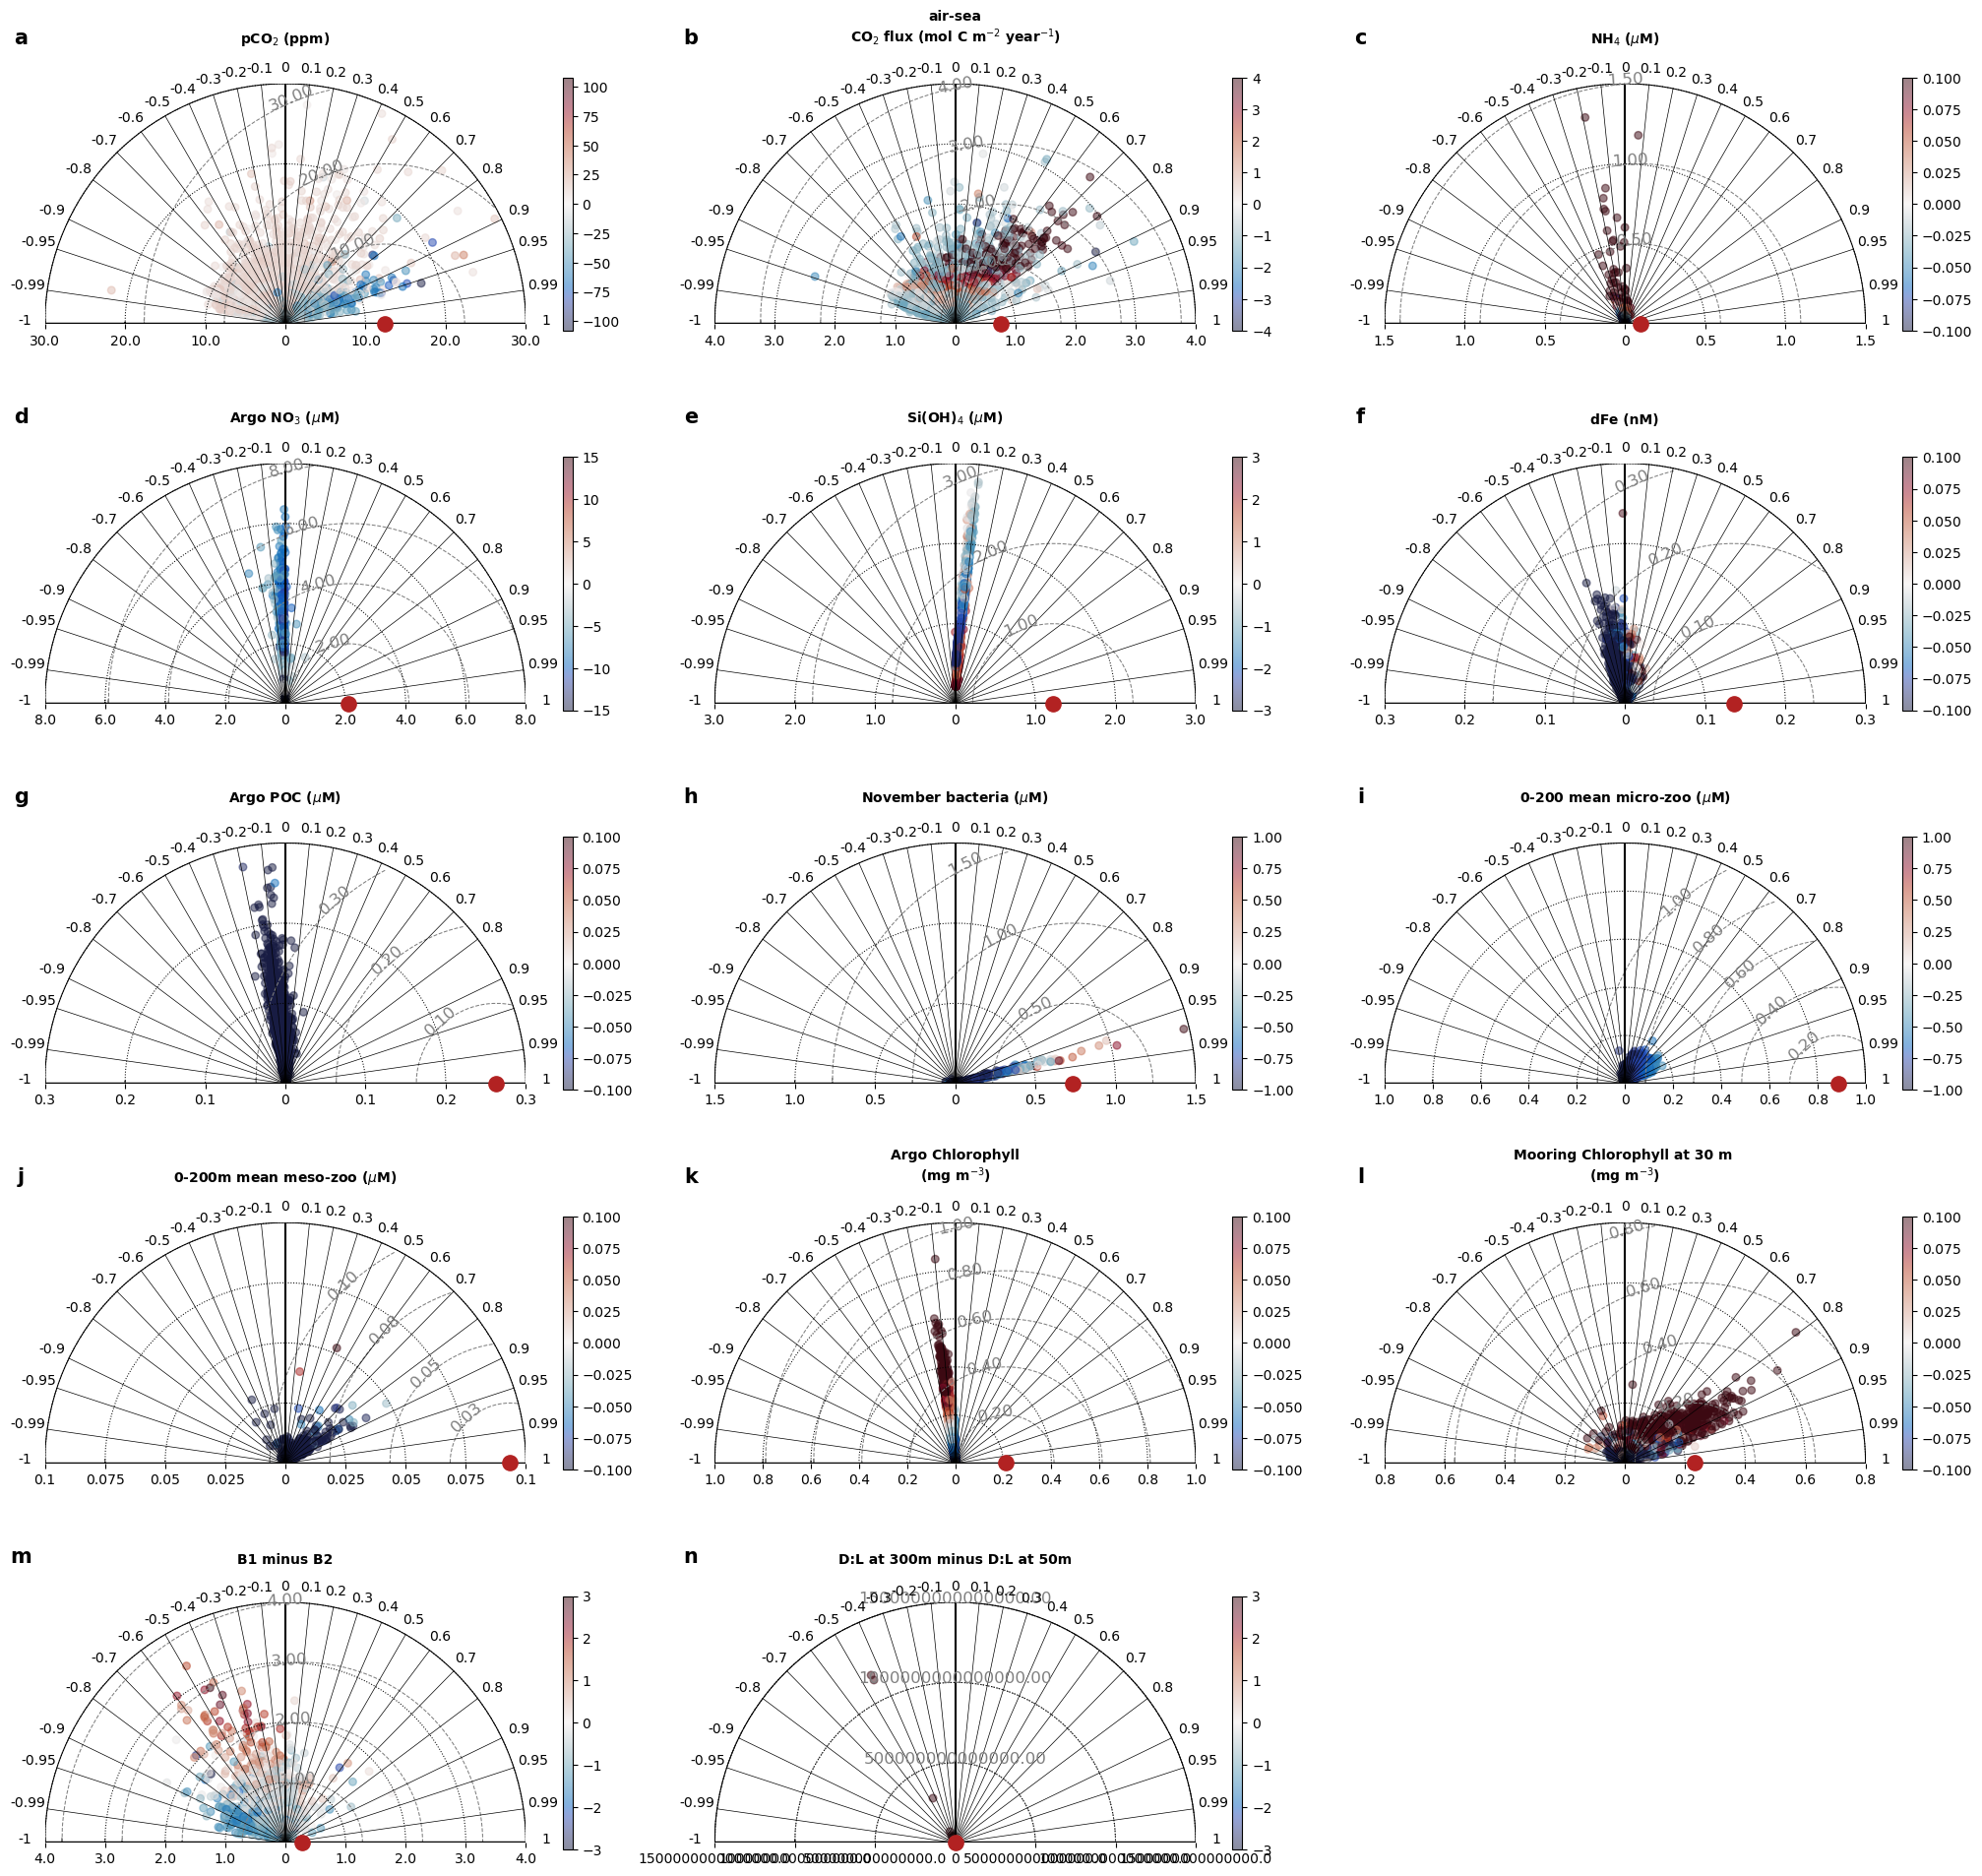

In [88]:

fslab = 15
fstic = 13


labs = ['pCO$_2$ (ppm)', \
        'air-sea\nCO$_2$ flux (mol C m$^{-2}$ year$^{-1}$)', \
        'NH$_4$ ($\mu$M)', \
        'Argo NO$_3$ ($\mu$M)', \
        'Si(OH)$_4$ ($\mu$M)', \
        'dFe (nM)', \
        'Argo POC ($\mu$M)', \
        'November bacteria ($\mu$M)', \
        '0-200 mean micro-zoo ($\mu$M)', \
        '0-200m mean meso-zoo ($\mu$M)', \
        'Argo Chlorophyll\n(mg m$^{-3}$)', \
        'Mooring Chlorophyll at 30 m \n(mg m$^{-3}$)', \
        'B1 minus B2', \
        'D:L at 300m minus D:L at 50m'
        ] 
letter = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n']

fig = plt.figure(figsize=(22,20))
gs = GridSpec(5, 3)

for vi,vv in enumerate(target_vars):
    ax = plt.subplot(gs[vi])

    vmin = 0 - np.abs(np.round(np.percentile(stats[vv+'_bias'],0.01),1)*1.2)
    vmax = 0 + np.abs(np.round(np.percentile(stats[vv+'_bias'],0.01),1)*1.2)
    vmin = 0 - np.abs(np.round(np.min(stats[vv+'_bias'])))
    vmax = 0 + np.abs(np.round(np.min(stats[vv+'_bias'])))
    statss = stats

    
    sm.taylor_diagram(np.array(statss[vv+'_sdev']), np.array(statss[vv+'_crmsd']), np.array(statss[vv+'_ccoef']), alpha=0.1, 
                      MarkerDisplayed='colorBar', cmapzdata=np.array(statss[vv+'_bias']), locationColorBar='EastOutside', titleColorBar=' ', 
                      cmap=lighten(cmo.balance,0.5), cmap_marker='o', markerSize=15, cmap_vmax=vmax, cmap_vmin=vmin, 
                      colRMS='grey', styleRMS='--', widthRMS=0.75, showlabelsRMS='on', titleRMS='off', rmsLabelFormat='0:.2f',
                      colSTD='k', styleSTD=':', widthSTD=0.75, showlabelsSTD='off', titleSTD='off', 
                      colCOR='k', styleCOR='-', widthCOR=0.5, showlabelsCOR='on', titleCOR='off', 
                      markerOBS='o', colOBS='firebrick')

    plt.text(0.5,1.15, labs[vi], transform=ax.transAxes, va='bottom', ha='center', fontweight='bold')
    plt.text(-0.05,1.15, letter[vi], fontweight='bold', fontsize=fslab, ha='center', va='bottom', transform=ax.transAxes)


plt.subplots_adjust(hspace=0.5, wspace=0.1, right=0.95, left=0.05, bottom=0.05, top=0.95)


os.chdir("/g/data/vn19/pjb581/SOTS-Optimization/WOMBATfull/figures")
fig.savefig("assess_performance_TaylorDiagram.png", dpi=300)
fig.savefig("assess_performance_TaylorDiagram.pdf", dpi=300)
fig.savefig("assess_performance_TaylorDiagram_transparent.png", dpi=300, transparent=True)


### Load the data and find out what the best experiments are

In [89]:
%%time

datadir = "/g/data/vn19/pjb581/SOTS-Optimization/WOMBATfull/data/output"

df_CCOEF = pd.read_excel(datadir + "/sensitivity_CCOEF.xlsx")

df_NRMSE = pd.read_excel(datadir + "/sensitivity_NRMSE.xlsx")

df_SDEV = pd.read_excel(datadir + "/sensitivity_SDEV.xlsx")

df_BIAS = pd.read_excel(datadir + "/sensitivity_BIAS.xlsx")


CPU times: user 1.21 s, sys: 47.6 ms, total: 1.26 s
Wall time: 1.23 s


In [90]:
df_NRMSE

,pco2_nrmse,fgco2_nrmse,nh4_nrmse,no3_nrmse,sil_nrmse,dfe_nrmse,poc_nrmse,bac_nrmse,micro_nrmse,meso_nrmse,chl_bottle_nrmse,chl_mooring_nrmse,b1mb2_nrmse,D2L300mD2L50_nrmse,sum_nrmse
0,1.353406,1.277538,1.442489,1.443881,1.357339,1.090042,1.436568,0.247263,1.035687,0.892316,1.471325,0.489911,1.573222,1.792654,16.903639
1,1.558783,1.460547,1.649702,1.448614,1.414317,0.952059,1.483171,0.206001,0.627397,1.521898,1.484863,0.608617,1.654260,1.064421,17.134649
2,1.757927,1.724832,1.447291,1.451333,1.388796,1.570438,1.502270,0.221941,1.199355,1.106509,1.504289,1.301325,1.712664,1.057608,18.946576
3,1.938055,1.944970,1.627071,1.444613,1.397604,1.259554,1.286343,0.193929,1.697848,1.056822,1.370456,1.077471,1.504532,1.071535,18.870802
4,1.915693,1.588324,1.630075,1.431937,1.378034,1.197267,1.492163,0.143992,1.548857,1.056822,1.499014,1.243769,1.938506,1.572131,19.636583
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2043,1.382648,1.321487,1.620200,1.445408,1.355349,1.441695,1.501370,0.221496,1.040868,1.501769,1.468488,0.663538,1.657909,1.145768,17.767994
2044,1.911842,1.872622,1.428386,1.464173,1.392675,1.427200,1.508418,1.971453,1.517042,1.103821,1.498487,1.956789,1.942484,0.757251,21.752642
2045,1.712579,1.724177,1.562474,1.459742,1.350243,0.953986,1.478720,0.220134,1.134685,1.304425,1.475229,0.622812,1.694105,1.759710,18.453023
2046,1.897308,1.671517,1.640041,1.444002,1.380177,1.362972,1.489018,0.196997,1.200123,1.174920,1.484630,1.014147,1.529764,1.546251,19.031867


In [91]:
df_NRMSE.sort_values(by="sum_nrmse", ascending=True)[0:20]

,pco2_nrmse,fgco2_nrmse,nh4_nrmse,no3_nrmse,sil_nrmse,dfe_nrmse,poc_nrmse,bac_nrmse,micro_nrmse,meso_nrmse,chl_bottle_nrmse,chl_mooring_nrmse,b1mb2_nrmse,D2L300mD2L50_nrmse,sum_nrmse
418,0.794811,0.749577,1.447705,1.435543,1.359928,1.153621,1.419795,0.229515,0.506186,0.821488,1.464952,0.512023,1.704140,0.928583,14.527867
533,0.448539,0.839535,1.636762,1.445599,1.393024,1.397143,1.458645,0.209321,1.040868,0.528673,1.488286,0.490728,1.477699,0.819539,14.674361
1699,0.602541,0.512697,1.584708,1.426372,1.372395,1.600672,1.386819,0.200147,1.202596,0.864738,1.430757,0.597203,1.323603,0.673580,14.778826
280,0.573244,0.590516,1.487939,1.430637,1.354103,1.194605,1.479349,0.215784,0.702845,0.928022,1.485218,0.635048,1.830760,0.925442,14.833513
1883,0.489146,0.404022,1.532285,1.432908,1.370730,1.378251,1.424024,0.210870,0.864448,0.907824,1.470363,0.571040,1.673921,1.108101,14.837932
1513,0.977782,0.910080,1.630972,1.384753,1.349054,1.008045,1.436217,0.213789,1.040868,0.485667,1.448453,0.400259,1.220782,1.370889,14.877612
297,0.751850,0.698279,1.383448,1.429640,1.358219,1.482090,1.478143,0.221064,0.895372,0.961484,1.468521,0.530190,1.634898,0.615336,14.908533
1660,0.742609,0.682747,1.637673,1.438768,1.347481,1.014852,1.464521,0.218937,0.977973,0.671573,1.440966,0.477946,1.701130,1.101963,14.919139
1036,0.726717,0.686377,1.604848,1.408250,1.360308,1.392470,1.392073,0.238535,0.835639,1.305240,1.484163,0.553927,1.759662,0.241103,14.989313
686,1.120304,1.061837,1.637977,1.435744,1.389427,1.237288,1.263399,0.268754,1.040868,0.511777,1.417129,0.428734,1.221023,0.960266,14.994528


In [96]:
df_NRMSE.sort_values(by="fgco2_nrmse", ascending=True)


,pco2_nrmse,fgco2_nrmse,nh4_nrmse,no3_nrmse,sil_nrmse,dfe_nrmse,poc_nrmse,bac_nrmse,micro_nrmse,meso_nrmse,chl_bottle_nrmse,chl_mooring_nrmse,b1mb2_nrmse,D2L300mD2L50_nrmse,sum_nrmse
1740,0.269864,0.272531,1.567997,1.455354,1.358345,1.577820,1.412750,1.813091,1.040868,1.056822,1.461714,0.378922,1.773916,1.085701,16.525694
1282,0.341484,0.319345,1.707385,1.457582,1.373152,1.573640,1.453528,1.972559,0.719220,1.056822,1.484711,0.489793,1.692100,1.204177,16.845496
1438,0.375098,0.347481,1.530777,1.427674,1.349919,1.038675,1.522817,0.223659,1.605660,1.056822,1.506339,1.022054,1.716262,1.348873,16.072112
1750,0.357185,0.350527,1.525801,1.433701,1.353264,1.528486,1.567149,0.222893,1.040868,1.494056,1.511147,0.815346,1.550222,1.620296,16.370940
448,0.350948,0.367420,1.481483,1.449015,1.362615,1.580294,1.468116,1.888082,1.571837,1.075448,1.500950,0.846543,1.623018,1.329062,17.894831
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1993,1.965657,1.978694,1.562379,1.431954,1.390250,1.188316,1.454603,0.180050,1.153172,1.056822,1.494717,0.823032,1.655955,1.299914,18.635516
1927,1.974682,1.978752,1.627529,1.428078,1.351932,1.552393,1.487430,0.298569,1.239598,1.116405,1.515907,1.417724,1.839917,1.891121,20.720036
875,1.964397,1.979424,1.636128,1.430802,1.376302,1.543352,1.454027,0.200386,1.043494,0.657160,1.451601,0.330149,1.439229,0.961481,17.467931
627,1.955714,1.979566,1.611635,1.426620,1.395291,1.441393,1.349550,0.210712,1.700818,1.056822,1.424137,0.423689,1.650093,0.641861,18.267899


In [113]:
fgco2_cost = (1.0 - df_CCOEF['fgco2_ccoef']) * df_NRMSE['fgco2_nrmse']

chl_cost = (1.0 - df_CCOEF['chl_mooring_ccoef']) * df_NRMSE['chl_mooring_nrmse']
print(fgco2_cost.sort_values(ascending=True)[0:20], chl_cost.sort_values(ascending=True)[0:20])

1740    0.010121
1282    0.016284
1438    0.020978
1750    0.021535
448     0.024800
1386    0.030216
222     0.030892
32      0.031722
1992    0.032796
1883    0.032975
1798    0.034024
470     0.036532
1968    0.039720
2024    0.042399
1521    0.044516
516     0.046260
1470    0.047021
1946    0.048765
1184    0.052139
574     0.052204
dtype: float64 625     0.001824
798     0.003650
11      0.005847
1471    0.006317
603     0.006322
1109    0.006418
158     0.007723
825     0.007801
91      0.008115
248     0.008209
1733    0.008426
1001    0.009031
341     0.009212
1543    0.010128
315     0.010160
1763    0.010239
193     0.010431
521     0.010566
1983    0.010809
437     0.011212
dtype: float64


In [100]:
df_cost = (1.0 - df_CCOEF['chl_mooring_ccoef']) * df_NRMSE['chl_mooring_nrmse']
df_cost

df_cost.sort_values(ascending=True)[0:20]

625     0.001824
798     0.003650
11      0.005847
1471    0.006317
603     0.006322
1109    0.006418
158     0.007723
825     0.007801
91      0.008115
248     0.008209
1733    0.008426
1001    0.009031
341     0.009212
1543    0.010128
315     0.010160
1763    0.010239
193     0.010431
521     0.010566
1983    0.010809
437     0.011212
dtype: float64